<a href="https://colab.research.google.com/github/PravinV001/Python/blob/Class_N_Colab/Decision_Trees_Shivam_S_Jan30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demonstration of Class Weights

In [ ]:
import numpy as np
import pandas as pd

# Tiny imbalanced dataset: 8 zeros, 2 ones
df = pd.DataFrame({
    "row": range(1, 11),
    "y":   [0,0,0,0,0,0,0,0,1,1],
    "p_hat":[0.05,0.10,0.02,0.15,0.07,0.03,0.12,0.08,0.20,0.60]
})

df

,row,y,p_hat
0,1,0,0.05
1,2,0,0.10
2,3,0,0.02
3,4,0,0.15
4,5,0,0.07
5,6,0,0.03
6,7,0,0.12
7,8,0,0.08
8,9,1,0.20
9,10,1,0.60


In [ ]:
p = df["p_hat"]
y = df['y']

df['bce'] = - (y * np.log(p) + (1 - y) * np.log(1 - p))
df

,row,y,p_hat,bce
0,1,0,0.05,0.051293
1,2,0,0.10,0.105361
2,3,0,0.02,0.020203
3,4,0,0.15,0.162519
4,5,0,0.07,0.072571
5,6,0,0.03,0.030459
6,7,0,0.12,0.127833
7,8,0,0.08,0.083382
8,9,1,0.20,1.609438
9,10,1,0.60,0.510826


In [ ]:
print("mean loss: ", df['bce'].mean())

mean loss:  0.27738838638292423


In [ ]:
w_pos = 10

df['w_class'] = np.where(df['y'].eq(1), w_pos, 1)
df

,row,y,p_hat,bce,w_class
0,1,0,0.05,0.051293,1
1,2,0,0.10,0.105361,1
2,3,0,0.02,0.020203,1
3,4,0,0.15,0.162519,1
4,5,0,0.07,0.072571,1
5,6,0,0.03,0.030459,1
6,7,0,0.12,0.127833,1
7,8,0,0.08,0.083382,1
8,9,1,0.20,1.609438,10
9,10,1,0.60,0.510826,10


In [ ]:
df['weighted_loss'] = df['bce'] * df['w_class']
df

,row,y,p_hat,bce,w_class,weighted_loss
0,1,0,0.05,0.051293,1,0.051293
1,2,0,0.10,0.105361,1,0.105361
2,3,0,0.02,0.020203,1,0.020203
3,4,0,0.15,0.162519,1,0.162519
4,5,0,0.07,0.072571,1,0.072571
5,6,0,0.03,0.030459,1,0.030459
6,7,0,0.12,0.127833,1,0.127833
7,8,0,0.08,0.083382,1,0.083382
8,9,1,0.20,1.609438,10,16.094379
9,10,1,0.60,0.510826,10,5.108256


In [ ]:
df['y'].value_counts() # no of majority class / no of minority class

,count
y,
0,8
1,2


In [ ]:
print("new mean loss: ", df['weighted_loss'].mean())

new mean loss:  2.185625568963006


In [ ]:
(df["y"].eq(0).sum()) / (df["y"].eq(1).sum())

np.float64(4.0)

# Demonstration of SMOTE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

rng = np.random.default_rng(70)

#  1) Create a 2D imbalanced dataset
n_majority = 500
n_minority = 50

X_majority = rng.normal(loc=[0.0, 0.0], scale=[1.0, 1.0], size=(n_majority, 2))
X_minority = rng.normal(loc=[2.5, 2.0], scale=[0.6, 0.6], size=(n_minority, 2))

X = np.vstack([X_majority, X_minority])
y = np.hstack([np.zeros(n_majority, dtype=int), np.ones(n_minority, dtype=int)])  #

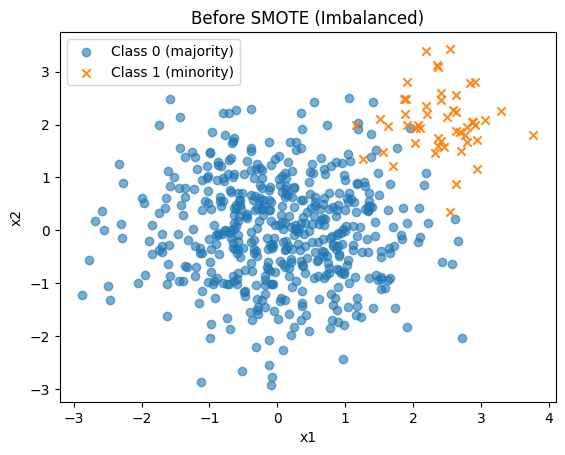

In [ ]:
plt.figure()
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0 (majority)", alpha=0.6)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1 (minority)", alpha=0.9, marker="x")
plt.title("Before SMOTE (Imbalanced)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()


In [ ]:
# X, y
np.unique(y, return_counts=True)

(array([0, 1]), array([500,  50]))

In [ ]:
X.shape, y.shape

((550, 2), (550,))

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(k_neighbors=5, random_state=7)

X_after, y_after = smote.fit_resample(X, y)

In [ ]:
X_after.shape, y_after.shape

((1000, 2), (1000,))

In [ ]:

np.unique(y_after, return_counts=True)

(array([0, 1]), array([500, 500]))

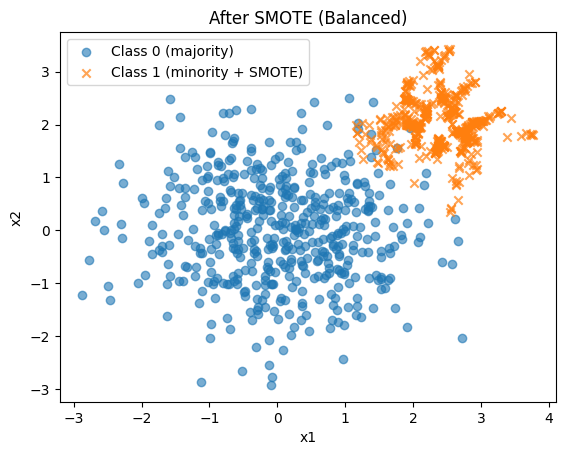

In [ ]:
#  4) Plot after SMOTE
plt.figure()
plt.scatter(X_after[y_after == 0, 0], X_after[y_after == 0, 1], label="Class 0 (majority)", alpha=0.6)
plt.scatter(X_after[y_after == 1, 0], X_after[y_after == 1, 1], label="Class 1 (minority + SMOTE)", alpha=0.7, marker="x")
plt.title("After SMOTE (Balanced)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()


# Employ Attrition Case Study

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io

In [ ]:
!gdown 16KtxSt_QEGQvfluEaMls5cCHPwhRXgCk


Downloading...
From: https://drive.google.com/uc?id=16KtxSt_QEGQvfluEaMls5cCHPwhRXgCk
To: /content/HR-Employee-Attrition.csv
100% 228k/228k [00:00<00:00, 104MB/s]


In [ ]:
df = pd.read_csv("HR-Employee-Attrition.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
from sklearn.tree import DecisionTreeClassifier
